[Home](../../README.md)

### Model Training - Polynomial Regression

Linear regression assumes the data has a linear pattern. If your data does not have a linear pattern you can consider a polynomial regression algorithm that provides a multi (poly) coefficient linear relationship between an independent variable and a dependent variable to predict the outcome of future events. We will now Train a Polynomial regression algorithm on the features you have engineered to see how closely we can predict the health outcomes for individuals.

#### Step 1

Load the required dependencies:

In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pickle

In [2]:
training_data = pd.read_csv('AAA_training_data.csv')


#### Step 2

Store the data columns for Linear Regression.

In [3]:
x_name = ['Platform', 'Genre']
y_name = 'Global_Sales'
x = np.array(training_data[x_name])
y = np.array(training_data[y_name])

#### Step 3

Plot the feature `x` and target `y` data on a graph using the column headings as the graph labels.

In [4]:
#for some reason this code keeps taking ages to run and throwing an error - the predictions graphs run fine, so I'm just commenting this out for now
#if(len(x_name) == 1):
#    plt.scatter(x, y, marker='x', c='r')
#    plt.title("Global sales vs publisher")
#    plt.ylabel(f'Training {y}')
#    plt.xlabel(f'Training {x[0]}')
#else:
#    fig,ax=plt.subplots(1,len(x),figsize=(12,3))
#    for i in range(len(ax)):
#        ax[i].scatter(x[:,i],y, label = 'Global_Sales')
#        ax[i].set_xlabel(x[i])
#    ax[0].set_ylabel("Global_Sales"); ax[0].legend();
#    fig.suptitle("Global sales vs... a lot.")
#plt.show()

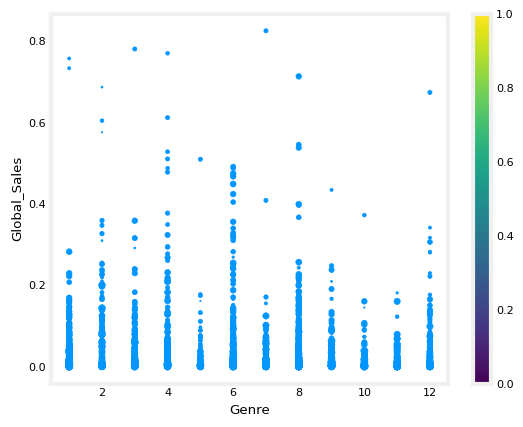

In [5]:
ax = plt.scatter(training_data.Genre, training_data.Global_Sales, training_data.Platform)
plt.xlabel("Genre")
plt.ylabel("Global_Sales")
plt.colorbar()
plt.show()

#### Step 4

Then save an instance of PolynomialFeatures, adjust the 'degree' parameter to suit your model and create the feature using the data in 'x'. (Note a degree of 1 is linear regression, each extra degree adds a coefficient).

Then use the [Scikit-learn](https://scikit-learn.org/stable/) library to instantiate a Machine Learning model class and store it in the `my_model` variable as an object.

In [6]:
poly = PolynomialFeatures(degree=10, include_bias=False)
poly_features = poly.fit_transform(x)

# Create the model
my_model = LinearRegression()
# Fit the model to the data
test = my_model.fit(poly_features, y)

/home/vscode/.local/lib/python3.11/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 0, 'Training Platform')

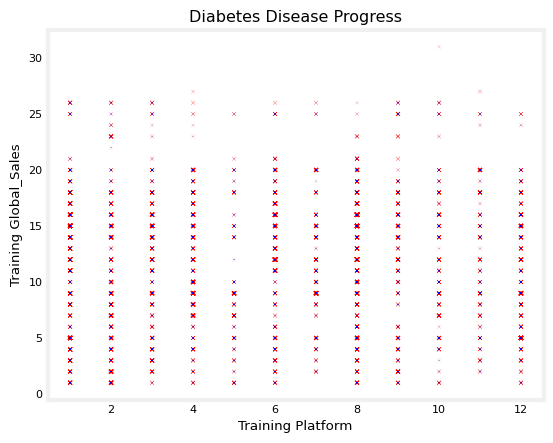

In [7]:
y_pred = my_model.predict(poly_features)
plt.scatter(training_data.Genre, training_data.Platform, y, marker='x',c='r')
plt.scatter(training_data.Genre, training_data.Platform, y_pred,c='b')
plt.title("Diabetes Disease Progress")
plt.ylabel(f'Training {y_name}')
plt.xlabel(f'Training {x_name[0]}')

### Prediction
Testing how well the model predicts specific numbers. This is what the results would look like on the finished website. 

In [8]:
new_game = pd.DataFrame({
    'Genre': [12],
    'Platform': [5]
})
new_poly_features = poly.fit_transform(new_game)
new_game['Global_Sales'] = my_model.predict(new_poly_features)

scale_feature = new_game['Global_Sales']

MIN_NG = 0

MAX_NG = 30

#scale features
newgame = (scale_feature + MIN_NG) * (MAX_NG + MIN_NG) 

print(f"New game data:\n{newgame}")



New game data:
0    1.448996
Name: Global_Sales, dtype: float64


In [9]:
#calculating the model's cost
test_score = my_model.score(new_poly_features, y_pred)
print(f'Training data score: {test_score}')

ValueError: Found input variables with inconsistent numbers of samples: [6360, 1]

In [ ]:
table = pd.DataFrame({
    training_data.columns[0]: x.flatten(),  
    training_data.columns[1]: y_pred,
    'Predicted result':my_model.predict(new_poly_features),
    'Loss' : abs(my_model.predict(new_poly_features).round(2) - y_pred)**2
})
print(table)
cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()

print(f"The cost or average loss of this model is {cost}")

ValueError: All arrays must be of the same length

In [ ]:
#calculating the model intercept and coefficient
print(f'X Axis intercept: {my_model.intercept_}')
print(f'Coefficient: {my_model.coef_}')

X Axis intercept: 0.03691386323635604
Coefficient: [-1.69364507e-07  4.59278630e-08 -1.03846280e-06 -1.09404654e-07
  1.40160696e-07 -4.25482563e-06  8.16740845e-08 -6.28634612e-07
  3.74734913e-07 -1.08918597e-05  5.88434495e-06 -1.13561192e-06
 -3.05068843e-06  1.04240797e-06 -7.77275017e-06  2.96606044e-05
  5.84445846e-06 -5.56022256e-06 -9.18012191e-06  2.69493242e-06
  2.40826581e-06 -7.85014808e-06 -2.50102987e-06  1.12244454e-05
 -6.95394259e-06 -1.47858354e-05  4.50492608e-06 -2.63198362e-07
  9.73547602e-07 -9.94081910e-07  2.62734913e-06 -4.82210126e-06
  3.09466318e-06  3.90672298e-06 -7.50207386e-07  1.38502098e-08
 -5.87776583e-08  1.13510772e-07 -2.85489825e-07  3.60513557e-07
 -8.81473213e-08 -1.44680712e-07 -3.15134592e-07 -4.24245535e-08
 -3.54572831e-10  1.64322637e-09 -3.57871632e-09  6.30183885e-09
  1.06900977e-09 -1.80343069e-08  1.59238793e-08  9.93761628e-09
 -1.03363767e-09  1.26060981e-08  3.54226105e-12 -1.69274068e-11
  3.07847705e-11  6.76043343e-12 -2.706

#### Step 5

Plot the features, targets and model (linear regression).

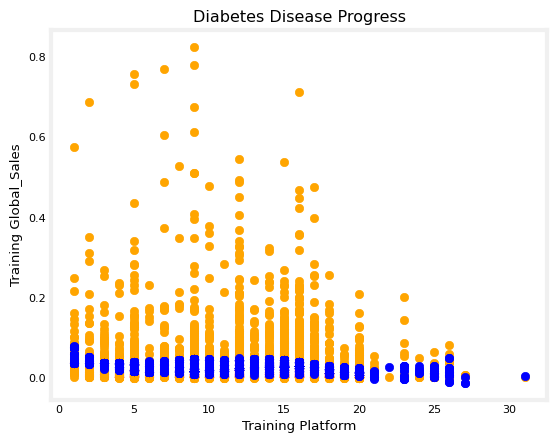

In [ ]:
y_pred = my_model.predict(poly_features)
if(len(x_name) != 1):
    plt.scatter(training_data.Platform, y, color="Orange")
    plt.scatter(training_data.Platform, y_pred, color="Blue")
    plt.title("Diabetes Disease Progress")
    plt.ylabel(f'Training {y_name}')
    plt.xlabel(f'Training {x_name[0]}')
else:
    fig,ax=plt.subplots(1,len(x_name),figsize=(12,3),sharey=True)
    for i in range(len(ax)):
        ax[i].scatter(x[:,i],y, label = 'target')
        ax[i].set_xlabel(x_name[i])
        ax[i].scatter(x[:,i],y_pred,color="orange", label = 'predict')
    ax[0].set_ylabel("Target"); ax[0].legend();
    fig.suptitle("Diabetes Disease Progress")
plt.show()

In [ ]:
# save the poly to disk
poly_filename = 'model_AAA.pkl'
pickle.dump(poly, open('../2.4.Model_Testing_and_Validation/' + poly_filename, 'wb'))

# save the model to disk
model_filename = 'model_AAA.sav'
pickle.dump(my_model, open('../2.4.Model_Testing_and_Validation/' + model_filename, 'wb'))

#### Step 6. Explore polynomial degrees

Students should now use the best features from Multiple Fetaure Linear Regression and apply some polynomial degrees to see if they can further improve the intuation of their model without overfitting.